
Linear Regression
MAE  : 1474748.13
MSE  : 3675286604768.19
RMSE : 1917103.7
R2   : 0.2729

Multiple Linear Regression
MAE  : 979679.69
MSE  : 1771751116594.03
RMSE : 1331071.42
R2   : 0.6495

Random Forest
MAE  : 1025289.68
MSE  : 1963538216518.65
RMSE : 1401263.08
R2   : 0.6115


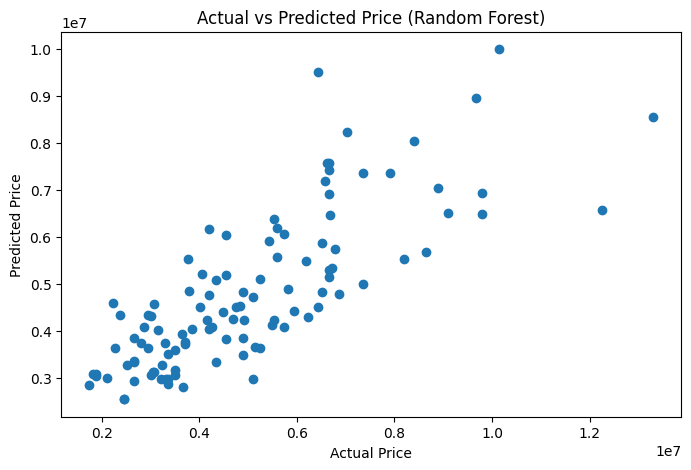

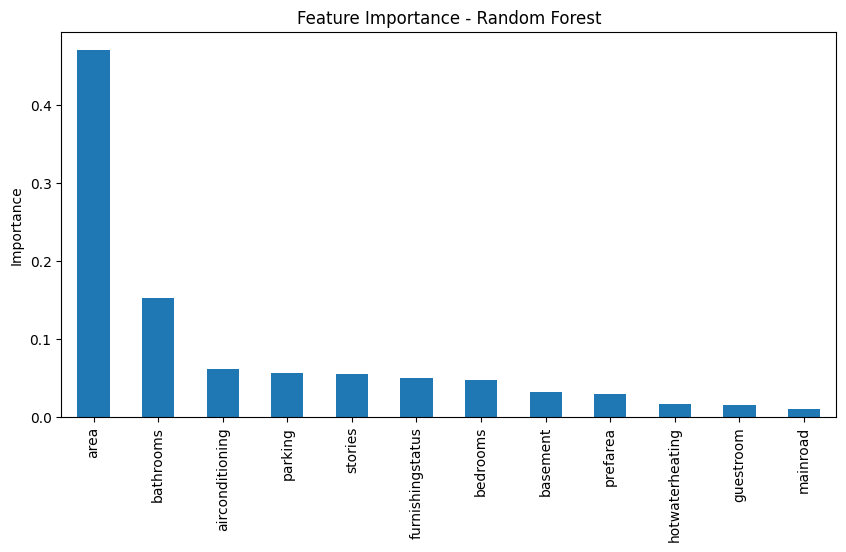


Enter Housing Details


Area:  2000
Bedrooms:  4
Bathrooms:  4
Stories:  2
Mainroad (yes/no):  yes
Guestroom (yes/no):  yes
Basement (yes/no):  yes
Hot Water Heating (yes/no):  no
Air Conditioning (yes/no):  yes
Parking Spaces:  2
Preferred Area (yes/no):  yes
Furnishing Status (furnished/semi-furnished/unfurnished):  furnished



Predicted House Price = ₹ 5658415.0


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =========================
# Load Dataset
# =========================
df = pd.read_csv("C:/Users/user/Downloads/Housing.csv")

# =========================
# Encode Categorical Columns
# =========================
le_dict = {}

for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le

# =========================
# Linear Regression
# (Using single feature AREA)
# =========================
X_linear = df[['area']]
y = df['price']

X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    X_linear, y, test_size=0.2, random_state=42
)

linear_model = LinearRegression()
linear_model.fit(X_train_l, y_train_l)

y_pred_linear = linear_model.predict(X_test_l)

# =========================
# Multiple Linear Regression
# =========================
X_multi = df.drop('price', axis=1)

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y, test_size=0.2, random_state=42
)

multi_model = LinearRegression()
multi_model.fit(X_train_m, y_train_m)

y_pred_multi = multi_model.predict(X_test_m)

# =========================
# Random Forest Regressor
# =========================
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_m, y_train_m)

y_pred_rf = rf_model.predict(X_test_m)

# =========================
# Function for Metrics
# =========================
def evaluate_model(name, y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print("\n" + "="*50)
    print(name)
    print("="*50)
    print("MAE  :", round(mae,2))
    print("MSE  :", round(mse,2))
    print("RMSE :", round(rmse,2))
    print("R2   :", round(r2,4))

# =========================
# Display Metrics
# =========================
evaluate_model("Linear Regression", y_test_l, y_pred_linear)
evaluate_model("Multiple Linear Regression", y_test_m, y_pred_multi)
evaluate_model("Random Forest", y_test_m, y_pred_rf)

# =========================
# CHART 1
# Actual vs Predicted
# =========================
plt.figure(figsize=(8,5))
plt.scatter(y_test_m, y_pred_rf)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price (Random Forest)")
plt.show()

# =========================
# CHART 2
# Feature Importance
# =========================
importance = pd.Series(
    rf_model.feature_importances_,
    index=X_multi.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,5))
importance.plot(kind='bar')
plt.title("Feature Importance - Random Forest")
plt.ylabel("Importance")
plt.show()

# =========================
# USER INPUT PREDICTION
# =========================
print("\nEnter Housing Details")

area = float(input("Area: "))
bedrooms = int(input("Bedrooms: "))
bathrooms = int(input("Bathrooms: "))
stories = int(input("Stories: "))
mainroad = input("Mainroad (yes/no): ")
guestroom = input("Guestroom (yes/no): ")
basement = input("Basement (yes/no): ")
hotwaterheating = input("Hot Water Heating (yes/no): ")
airconditioning = input("Air Conditioning (yes/no): ")
parking = int(input("Parking Spaces: "))
prefarea = input("Preferred Area (yes/no): ")
furnishingstatus = input(
    "Furnishing Status (furnished/semi-furnished/unfurnished): "
)

# Encode user input
user_data = pd.DataFrame({
    'area':[area],
    'bedrooms':[bedrooms],
    'bathrooms':[bathrooms],
    'stories':[stories],
    'mainroad':[le_dict['mainroad'].transform([mainroad])[0]],
    'guestroom':[le_dict['guestroom'].transform([guestroom])[0]],
    'basement':[le_dict['basement'].transform([basement])[0]],
    'hotwaterheating':[le_dict['hotwaterheating'].transform([hotwaterheating])[0]],
    'airconditioning':[le_dict['airconditioning'].transform([airconditioning])[0]],
    'parking':[parking],
    'prefarea':[le_dict['prefarea'].transform([prefarea])[0]],
    'furnishingstatus':[le_dict['furnishingstatus'].transform([furnishingstatus])[0]]
})

predicted_price = rf_model.predict(user_data)

print("\nPredicted House Price = ₹", round(predicted_price[0],2))

In [2]:
import streamlit as st
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# 1. Load and Prepare Data (Cached for performance)
@st.cache_resource
def get_model():
    df = pd.read_csv("C:/Users/user/Downloads/Housing.csv") # Ensure Housing.csv is in the same folder
    le_dict = {}
    for col in df.select_dtypes(include='object').columns:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        le_dict[col] = le
    
    X = df.drop('price', axis=1)
    y = df['price']
    rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_model.fit(X, y)
    return rf_model, le_dict

model, le_dict = get_model()

# 2. UI Layout
st.title("🏡 Housing Price Predictor")
st.write("Enter the details of the house to get a price prediction.")

col1, col2 = st.columns(2)

with col1:
    area = st.number_input("Area (sq ft)", min_value=1000, value=5000)
    bedrooms = st.slider("Bedrooms", 1, 6, 3)
    bathrooms = st.slider("Bathrooms", 1, 4, 2)
    stories = st.slider("Stories", 1, 4, 2)
    parking = st.slider("Parking Spaces", 0, 3, 1)

with col2:
    mainroad = st.selectbox("Mainroad", ["yes", "no"])
    guestroom = st.selectbox("Guestroom", ["yes", "no"])
    basement = st.selectbox("Basement", ["yes", "no"])
    hotwaterheating = st.selectbox("Hot Water Heating", ["yes", "no"])
    airconditioning = st.selectbox("Air Conditioning", ["yes", "no"])
    prefarea = st.selectbox("Preferred Area", ["yes", "no"])
    furnishingstatus = st.selectbox("Furnishing Status", ["furnished", "semi-furnished", "unfurnished"])

# 3. Prediction Logic
if st.button("Predict Price"):
    input_data = pd.DataFrame({
        'area': [area], 'bedrooms': [bedrooms], 'bathrooms': [bathrooms], 
        'stories': [stories], 'parking': [parking],
        'mainroad': [le_dict['mainroad'].transform([mainroad])[0]],
        'guestroom': [le_dict['guestroom'].transform([guestroom])[0]],
        'basement': [le_dict['basement'].transform([basement])[0]],
        'hotwaterheating': [le_dict['hotwaterheating'].transform([hotwaterheating])[0]],
        'airconditioning': [le_dict['airconditioning'].transform([airconditioning])[0]],
        'prefarea': [le_dict['prefarea'].transform([prefarea])[0]],
        'furnishingstatus': [le_dict['furnishingstatus'].transform([furnishingstatus])[0]]
    })
    
    prediction = model.predict(input_data)
    st.success(f"### Predicted House Price: ₹{round(prediction[0], 2):,}")

2026-06-26 13:56:54.141 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-26 13:56:54.728 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-26 13:56:54.858 
  command:

    streamlit run C:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-06-26 13:56:54.861 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-26 13:56:54.863 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-26 13:56:54.865 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-26 13:56:54.868 Thread 'MainThread': missing ScriptRunContext! This war